# EDA 01: HPA RNA Expression

## Purpose

`1_4_hpa_rna_celline.tsv` is one of two independent RNA-expression measurements in the primary
dataset (the other is DepMap RNA, notebook 02). It is long-format: one row per (gene, cell line)
pair, sourced from the Human Protein Atlas (HPA) — a different lab, different platform, and a
different normalisation pipeline than DepMap. Its main job in this pipeline is not to be *the*
expression layer, but to **corroborate** the DepMap layer: when a gene's call agrees across both
sources, that is a stronger evidence signal than either alone
(`docs/PROJECT_ARCHITECTURE.md` §0 — confidence means strength **and** cross-source consistency).

**Source, release, grain:** Human Protein Atlas, cell-line RNA-seq (`proteinatlas.org`). Long
format — one row per (`Gene`, `Cell line`) pair. ~24.3M rows, 20,162 genes, 1,206 cell lines. No
release date is embedded in the file; treat as a single snapshot (`docs/reference/DATA_SOURCES.md`).

## Questions this notebook must answer

1. Is the table's grain really one row per (gene, cell line), with a clean primary key?
2. Is `Gene` (Ensembl ID) safe to use as the join key, or does `Gene name` collide?
3. What does a zero mean here, and how common is it?
4. How is `nTPM` distributed, and does it need a transform before use?
5. Which genes and cell lines carry the most information (highest variance)?
6. What is the identity path from this table's free-text `Cell line` name to the primary identity
   spine (file 9), and how much is lost at each hop?
7. Does transcriptional activity vary systematically by lineage — a stratification concern for
   later notebooks, not a causal claim here?

**Interpretation rule:** every (gene, cell line) pair present in this table is `measured`
(`docs/PROJECT_ARCHITECTURE.md` §7). A zero `nTPM` is `measured_absent` — the assay ran and found
no transcript, a real biological reading. A gene or cell line that never appears in this table at
all is `not_assayed` for HPA RNA specifically, not for RNA expression in general (DepMap RNA,
notebook 02, may still cover it).

## Column dictionary

| Column | Meaning | Notes |
|---|---|---|
| `Gene` | Ensembl gene ID (`ENSG...`) | **primary key — always join/group on this** |
| `Gene name` | HGNC symbol | **not safe as a key** — 10 symbols map to >1 Ensembl ID |
| `Cell line` | free-text HPA cell-line name | join key to file 11 (`11_hpa_rna_celline_description`), not directly to file 9 |
| `TPM` | transcripts per million | raw |
| `pTPM` | protein-coding-renormalised TPM | |
| `nTPM` | normalised TPM | preferred metric for cross-line comparison — accounts for gene length and depth |

## 1. Basic data contract and schema audit

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
RAW = ROOT / 'data' / 'raw'
GENE_EXPRESSION = RAW / 'gene_expression'
NOMENCLATURE = RAW / 'nomenclature'
GENE_PROPERTIES = RAW / 'gene_properties'
NON_GENE_EXPRESSION = RAW / 'non_gene_expression'
AUGMENTED = ROOT / 'data' / 'augmented'

In [2]:
%%time
df = pd.read_csv(GENE_EXPRESSION / '1_4_hpa_rna_celline.tsv', sep='\t')
df.shape

CPU times: total: 22.8 s
Wall time: 23.9 s


(24315372, 6)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24315372 entries, 0 to 24315371
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Gene       str    
 1   Gene name  str    
 2   Cell line  str    
 3   TPM        float64
 4   pTPM       float64
 5   nTPM       float64
dtypes: float64(3), str(3)
memory usage: 1.7 GB


In [4]:
df.head()

,Gene,Gene name,Cell line,TPM,pTPM,nTPM
0,ENSG00000000003,TSPAN6,143B,22.0,27.6,25.9
1,ENSG00000000003,TSPAN6,22Rv1,2.8,3.6,2.7
2,ENSG00000000003,TSPAN6,23132/87,6.2,7.5,7.5
3,ENSG00000000003,TSPAN6,253J,14.2,18.7,25.4
4,ENSG00000000003,TSPAN6,253J-BV,13.0,17.1,18.5


In [5]:
df["Gene"].nunique(), df["Gene name"].nunique(), df["Cell line"].nunique()

(20162, 20151, 1206)

### Why this EDA check matters

This confirms the grain assumption — long format, one row per (gene, cell line) — before anything
downstream treats the table as tidy. `df.shape[0]` should be close to
`nunique(Gene) * nunique(Cell line)`; a large shortfall would mean the table is not a dense
gene-by-cell-line grid and any pivot must handle missing combinations explicitly.

## 2. Gene identifier consistency (Ensembl vs symbol)

In [6]:
unique_pairs = df[['Gene', 'Gene name']].drop_duplicates()
name_counts = unique_pairs.groupby('Gene name')['Gene'].transform('nunique')
duplicated_names_df = unique_pairs[name_counts > 1].sort_values('Gene name')
duplicated_names_df

,Gene,Gene name
9141480,ENSG00000138641,HERC3
24174270,ENSG00000287542,HERC3
432954,ENSG00000015479,MATR3
23854680,ENSG00000280987,MATR3
6828372,ENSG00000125863,MKKS
24088644,ENSG00000285508,MKKS
24105528,ENSG00000285723,MKKS
22927266,ENSG00000255346,NOX5
24291252,ENSG00000290203,NOX5
18036936,ENSG00000183889,NPIPA9


In [7]:
missing_names = df[df['Gene name'].isna()]['Gene'].nunique()
print(f"Gene IDs missing a Gene Name: {missing_names}")

Gene IDs missing a Gene Name: 0


### Why this EDA check matters

If 10 gene *names* each resolve to more than one Ensembl ID (alternate GRCh38 contigs — the same
biological locus annotated twice), then grouping or merging on `Gene name` silently pools two
different rows into one. Any pipeline code (and the eventual scorer) must join and aggregate on
`Gene` (Ensembl ID), never `Gene name`.

## 3. Missingness and zero-value semantics

In [8]:
tpm_columns = ['TPM', 'pTPM', 'nTPM']
zero_stats = []
for col in tpm_columns:
    zero_count = (df[col] == 0).sum()
    zero_pct = zero_count / len(df) * 100
    na_count = df[col].isna().sum()
    zero_stats.append({'column': col, 'exact_zero_pct': round(zero_pct, 2), 'na_count': int(na_count)})
pd.DataFrame(zero_stats)

,column,exact_zero_pct,na_count
0,TPM,27.96,0
1,pTPM,26.36,0
2,nTPM,26.33,0


### Why this EDA check matters

A zero here is `measured_absent`, not missing — the assay ran and the gene was not detected in
that cell line. That is real biological signal (the gene is switched off in that cell context) and
must never be mean-imputed or treated the same as `not_assayed`. `NaN` counts (true missingness
within the table) are reported separately and should be ~0 if the table is a dense grid.

## 4. Expression value distributions

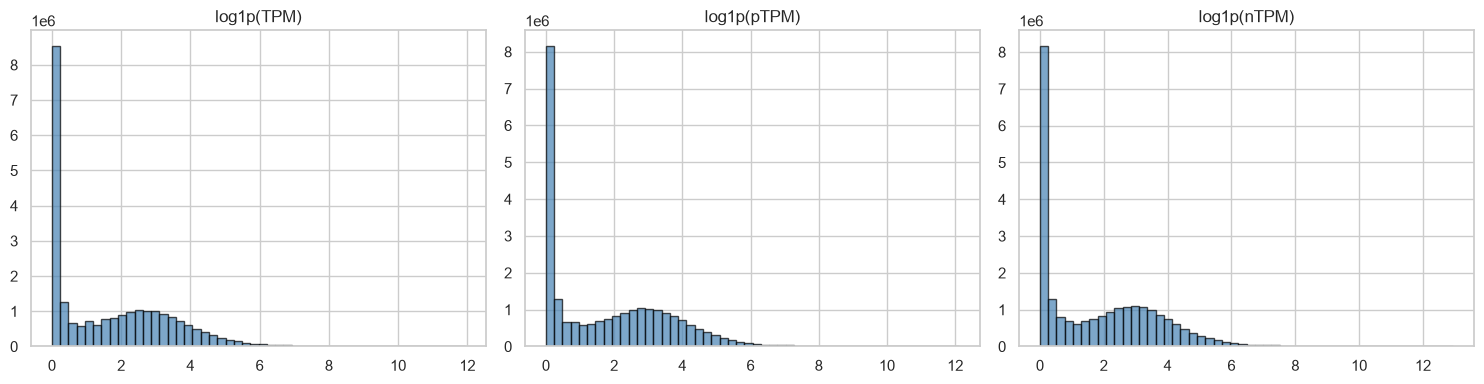

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, tpm_columns):
    ax.hist(np.log1p(df[col].dropna()), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'log1p({col})')
plt.tight_layout(); plt.show()

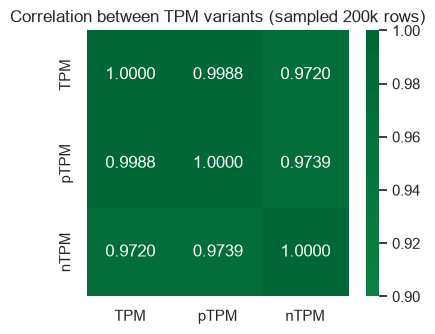

In [10]:
sample_df = df.sample(200_000, random_state=42)
corr_mat = sample_df[tpm_columns].corr()
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(corr_mat, annot=True, fmt='.4f', cmap='RdYlGn', center=0, vmin=0.9, vmax=1.0, ax=ax)
ax.set_title('Correlation between TPM variants (sampled 200k rows)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

All three TPM variants are heavily right-skewed (a small number of highly-expressed housekeeping
genes dominate the raw scale) — `log1p` is required before any visual or statistical use, matching
`data/raw/gene_expression/_.md`'s stated convention. TPM, pTPM and nTPM should be near-perfectly
correlated (all three measure the same underlying quantity at different normalisations); a material
drop in that correlation would flag a data-quality problem, not a biological one. `nTPM` is used
downstream because it also normalises for gene length, which the other two do not.

## 5. Per-gene and per-cell-line variability

In [11]:
%%time
gene_stats = df.groupby('Gene')['nTPM'].agg(['mean', 'std']).reset_index()
gene_stats = gene_stats.sort_values('std', ascending=False)
gene_stats.head(10)

CPU times: total: 1.33 s
Wall time: 1.34 s


,Gene,mean,std
18258,ENSG00000228253,30736.089801,27116.311793
16806,ENSG00000198712,23660.929104,21883.238699
16852,ENSG00000198804,18891.580846,19390.885632
16930,ENSG00000198938,16566.255721,14381.794215
17757,ENSG00000212907,13642.652570,11935.009524
16907,ENSG00000198899,13386.474378,11344.489813
16899,ENSG00000198886,10915.908126,10955.028060
17515,ENSG00000211675,420.512769,9512.201964
17465,ENSG00000211592,1071.169403,9509.073977
16874,ENSG00000198840,8371.099005,7839.043663


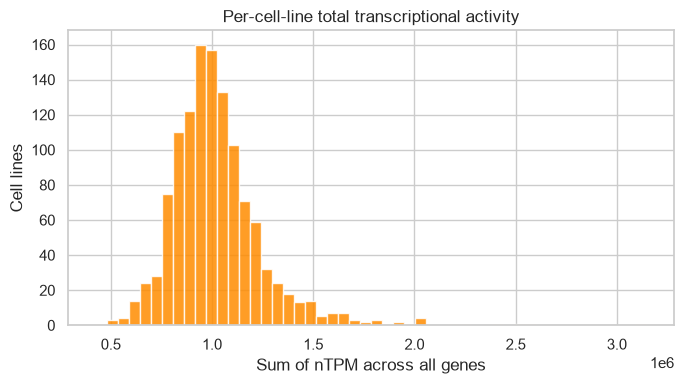

In [12]:
line_stats = df.groupby('Cell line')['nTPM'].agg(['sum', 'mean']).reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(line_stats['sum'], bins=50, color='darkorange', edgecolor='white', alpha=0.85)
ax.set_xlabel('Sum of nTPM across all genes'); ax.set_ylabel('Cell lines')
ax.set_title('Per-cell-line total transcriptional activity')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Genes with high variance across cell lines are the informative ones for distinguishing cell-line
identity (housekeeping genes, by contrast, sit at the top of the *mean* but near the bottom of the
*variance* ranking — they are always on, so they carry no discriminating signal). Per-cell-line
total activity is a coarse QC signal: an unusually low or high total can flag a library-prep or
normalisation outlier worth excluding from downstream lineage comparisons, not a biological
finding in itself.

## 6. Identity join path to the primary spine

HPA RNA uses a **free-text cell-line name** — the hardest identifier system in the primary set to
join. The path to the primary identity spine (file 9, `DepMap_ID`) is three hops long, and each hop
can lose rows:

| From | Key column | To | Key column | Notes |
|---|---|---|---|---|
| file 1 (this table) | `Cell line` | file 11 | `Cell line` | same HPA project; should be close to complete |
| file 11 | `Cellosaurus ID` | file 7 | `Accession (CVCL_xxxx)` | universal registry format |
| file 7 | `Accession` (via `RRID`) | file 9 | `RRID` | reaches the DepMap/primary identity world |

A cell line that falls off at any hop cannot be corroborated against DepMap RNA (notebook 02) or
joined to any other primary layer. Which lineages are lost at each hop tells us where a combined
HPA + DepMap comparison has blind spots — this is a coverage-bias check, not a value judgement
about HPA's data quality.

In [13]:
df11 = pd.read_csv(NOMENCLATURE / '11_hpa_rna_celline_description.tsv', sep='\t',
                    usecols=['Cell line', 'Cellosaurus ID'])
df7 = pd.read_csv(NOMENCLATURE / '7_cellosaurus.csv',
                   usecols=['Identifier (cell line name)', 'Accession (CVCL_xxxx)'])
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'RRID', 'lineage'])

hpa_lines = set(df['Cell line'].dropna().unique())
hop1_match = hpa_lines & set(df11['Cell line'].dropna())

hop1_cvcl = set(df11[df11['Cell line'].isin(hop1_match)]['Cellosaurus ID'].dropna())
hop2_match = hop1_cvcl & set(df7['Accession (CVCL_xxxx)'].dropna())

hop3_match = hop2_match & set(df9['RRID'].dropna())

print(f"HPA cell lines (file 1)                         : {len(hpa_lines)}")
print(f"Hop 1 -> file 11 by name                          : {len(hop1_match)} ({len(hop1_match)/len(hpa_lines):.1%})")
print(f"Hop 2 -> file 7 by Cellosaurus accession          : {len(hop2_match)} ({len(hop2_match)/len(hpa_lines):.1%})")
print(f"Hop 3 -> file 9 by RRID (reaches primary spine)   : {len(hop3_match)} ({len(hop3_match)/len(hpa_lines):.1%})")

HPA cell lines (file 1)                         : 1206
Hop 1 -> file 11 by name                          : 1206 (100.0%)
Hop 2 -> file 7 by Cellosaurus accession          : 1197 (99.3%)
Hop 3 -> file 9 by RRID (reaches primary spine)   : 1103 (91.5%)


In [14]:
lineage_reached = df9[df9['RRID'].isin(hop3_match)]['lineage'].value_counts()
print("Lineage breakdown of HPA lines that reach the primary spine (top 10):")
print(lineage_reached.head(10).to_string())

Lineage breakdown of HPA lines that reach the primary spine (top 10):
lineage
lung                      214
blood                      89
lymphocyte                 72
central_nervous_system     66
breast                     62
colorectal                 58
ovary                      56
skin                       54
pancreas                   45
fibroblast                 39


### Why this EDA check matters

The eligible denominator for "HPA-corroborated RNA evidence" is whatever survives all three hops —
not the raw 1,206 HPA cell lines. Reporting the HPA layer's coverage against the full 1,206 would
overstate how much corroboration is actually available once identity is resolved. The per-lineage
breakdown checks whether the loss is roughly uniform (an identity-resolution artefact, safe to
proceed) or concentrated in specific cancer types (a coverage bias that must be disclosed, per
`docs/PROJECT_ARCHITECTURE.md` §6 admission criterion A2).

## 7. Lineage context

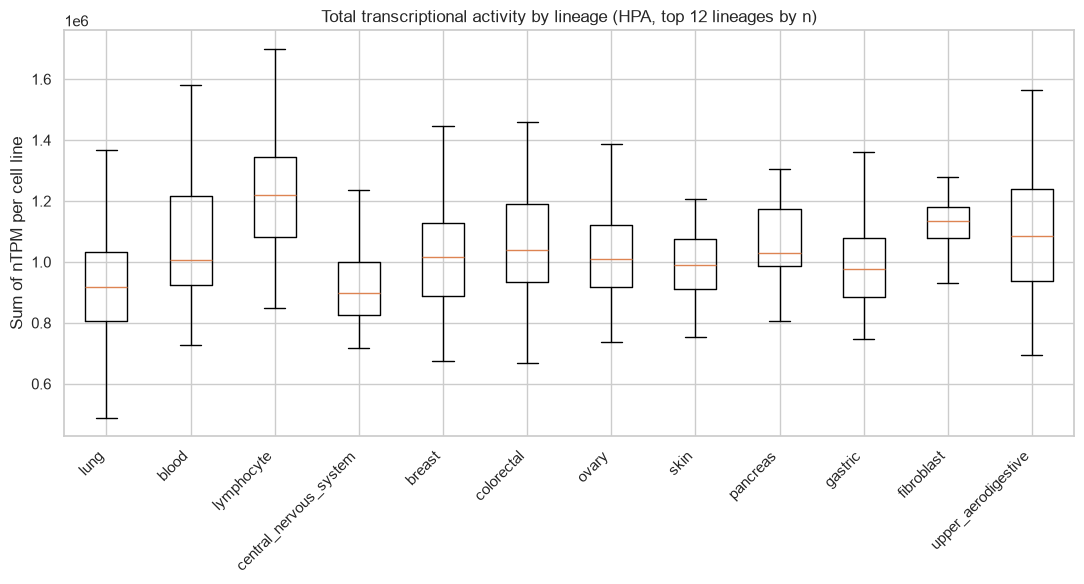

In [15]:
name_to_lineage = (df11.merge(df9, left_on='Cellosaurus ID', right_on='RRID', how='left')
                        .dropna(subset=['Cell line'])
                        .drop_duplicates('Cell line')
                        .set_index('Cell line')['lineage'])
ls = line_stats.copy()
ls['lineage'] = ls['Cell line'].map(name_to_lineage)
top_lineages = ls['lineage'].value_counts().head(12).index

fig, ax = plt.subplots(figsize=(11, 6))
ax.boxplot([ls.loc[ls.lineage == l, 'sum'].values for l in top_lineages],
           tick_labels=list(top_lineages), showfliers=False)
plt.xticks(rotation=45, ha='right')
ax.set_ylabel('Sum of nTPM per cell line')
ax.set_title('Total transcriptional activity by lineage (HPA, top 12 lineages by n)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

This is a **descriptive** check for whether total transcriptional output differs systematically by
lineage — a real difference here would mean pan-cancer comparisons of raw activity must be
lineage-stratified. **It is not evidence of *why* any lineage differs** — batch effects, tissue
composition, and true biology are all plausible and this plot cannot distinguish them. Per root
`_.md` §3, no causal claim is made from this correlation.

## Decisions carried into the next notebooks

1. **Always join and group on `Gene` (Ensembl ID), never `Gene name`** — 10 symbols collide.
2. **`nTPM` zeros are `measured_absent`, a real biological reading — never mean-impute them.**
3. HPA RNA reaches the primary identity spine only through a 3-hop bridge
   (`Cell line` → file 11 → file 7 → file 9 `RRID`); the loss at each hop (measured above) sets the
   real denominator for any HPA-corroborated evidence, and must be checked for lineage bias before
   being treated as uniform.
4. This layer's product role is **corroboration** of DepMap RNA (notebook 02), not a standalone
   scored layer — `docs/PROJECT_ARCHITECTURE.md` §0 frames confidence as strength *and*
   cross-source agreement, and this is the cross-source half for RNA.
5. **Limitation:** the lineage-activity comparison in §7 is descriptive only; it cannot separate
   assay batch effects from real biological differences and must not be read as a ranking signal on
   its own.